## 1. Setup and Installation

Install required packages and configure your environment.

In [1]:
# Install dependencies (run once)
import sys
!{sys.executable} -m pip install -q python-dotenv google-genai

print("✅ Dependencies installed")

✅ Dependencies installed


In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(f"✅ Project root: {project_root}")

✅ Project root: /workspaces/go2-odd-observer


## 2. Configure Google Gemini API

**Required:** Get your free API key at https://aistudio.google.com/app/apikey

In [3]:
# Option 1: Load from .env file (recommended)
load_dotenv()

# Option 2: Set directly (not recommended - don't commit this!)
# os.environ['GOOGLE_API_KEY'] = 'your-key-here'

# Verify API key
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')
if GOOGLE_API_KEY:
    print("✅ Google Gemini API configured")
    print(f"   Key: {GOOGLE_API_KEY[:8]}...{GOOGLE_API_KEY[-4:]}")
else:
    print("❌ GOOGLE_API_KEY not found!")
    print()
    print("Please set your API key:")
    print("  1. Get free key: https://aistudio.google.com/app/apikey")
    print("  2. Create a .env file with: GOOGLE_API_KEY=your-key-here")
    print("     OR set environment: export GOOGLE_API_KEY='your-key-here'")

✅ Google Gemini API configured
   Key: AIzaSyBG...YTN8


## 3. Define ODD Specification

Describe your robot's Operational Design Domain in natural language. The AI will parse this into a formal specification.

**Pipeline stages:**
1. **ODD Spec Agent** - Parse natural language ODD → formal specification
2. **Perception Agents** - Analyze camera + LiDAR images (loop + summary)
3. **Motion Agents** - Detect motion from IMU data (loop + summary)
4. **Collision Agents** - Assess collision risk (loop + summary)
5. **COD Classifier** - Determine current operating domain
6. **ODD Compliance** - Compare COD vs ODD, detect violations
7. **Report Generator** - Create comprehensive analysis report

In [ ]:
# Natural Language ODD Description
# Describe your robot's operating domain in PLAIN LANGUAGE - be conversational!
# The AI will convert this to a formal specification with precise ranges.

odd_description = """
The Unitree Go2 is a quadruped robot designed for indoor office navigation. 

It's meant to operate in typical office buildings - think conference rooms, hallways, 
and open workspaces. The floors should be smooth (tile, hardwood, or low-pile carpet), 
and there needs to be adequate lighting so the cameras can see clearly. Bright office 
lighting is ideal, but it can handle dimmer areas too. No pitch-black rooms though.

The robot moves with gentle, controlled acceleration - nothing crazy fast. Think smooth, 
deliberate movements, not sudden jerks or aggressive maneuvers. It's designed to navigate 
around typical office obstacles like chairs, desk legs, and the occasional box, but it's 
not meant for super cluttered spaces where there's barely room to move.

The robot expects relatively flat, stable ground. No stairs, no steep ramps, and 
definitely not designed for outdoor terrain like gravel or grass. It needs space 
to maneuver safely without constantly being on the verge of hitting things.

DEFINITELY NOT designed for:
- Outdoor environments (weather, uneven ground, GPS reliance)
- Staircases or steep slopes
- Dark rooms where vision sensors can't work
- Extremely crowded spaces where collision is almost guaranteed
- Rough terrain, gravel, sand, or anything unstable
"""

print(f"✅ ODD specification defined ({len(odd_description)} characters)")
print("\n💡 TIP: Describe your ODD in natural language - the AI handles formalization!")
print("   • Focus on WHERE the robot operates (environment, terrain)")
print("   • Mention WHAT it avoids (prohibited conditions)")
print("   • Describe HOW it moves (acceleration, stability expectations)")
print("   • The agent will infer precise ranges from your description")

✅ ODD specification defined (1233 characters)

💡 TIP: Describe your ODD in natural language - the AI handles formalization!
   • Focus on WHERE the robot operates (environment, terrain)
   • Mention WHAT it avoids (prohibited conditions)
   • Describe HOW it moves (speed, stability expectations)
   • The agent will infer precise ranges from your description


## 4. Select Scenario to Analyze

Choose which preprocessed dataset you want to analyze. Scenarios are stored in `data/processed/runs/`.

**Available scenarios:**
- `sim_run_test` - Small test dataset (2 windows)
- `demo_run` - Demo dataset for quick testing
- Your own scenarios (after running `extract_windows.py`)

In [ ]:
# List available scenarios
data_dir = project_root / "data" / "processed" / "runs"

if data_dir.exists():
    scenarios = [d.name for d in data_dir.iterdir() if d.is_dir()]
    print("📁 Available scenarios:")
    for i, scenario in enumerate(scenarios, 1):
        scenario_path = data_dir / scenario
        window_count = len(list(scenario_path.glob("motion_*.json")))
        print(f"   {i}. {scenario:20s} ({window_count:2d} windows)")
else:
    print("⚠️ Data directory not found!")
    print(f"   Expected: {data_dir}")
    print("   Run: python scripts/extract_windows.py first")
    scenarios = []

print()

# ========== CONFIGURATION: Select scenario ==========
SCENARIO_NAME = "sim_run_new"  # Full simulation dataset (13 windows)

if scenarios and SCENARIO_NAME in scenarios:
    SCENARIO_PATH = str((data_dir / SCENARIO_NAME).absolute())
    window_count = len(list((data_dir / SCENARIO_NAME).glob("motion_*.json")))
    print(f"✅ Selected: {SCENARIO_NAME}")
    print(f"   Windows: {window_count}")
    print(f"   Path: {SCENARIO_PATH}")
else:
    print(f"❌ Scenario '{SCENARIO_NAME}' not found!")
    if scenarios:
        print(f"   Available: {', '.join(scenarios)}")
    SCENARIO_PATH = None

📁 Available scenarios:
   1. demo_run             (10 windows)
   2. run_001              (11 windows)
   3. sim_run_new          (13 windows)
   4. sim_run_test         ( 2 windows)
   5. test_run             ( 2 windows)

✅ Selected: sim_run_test
   Windows: 2
   Path: /workspaces/go2-odd-observer/data/processed/runs/sim_run_test


## 5.1. Configure Models

Select which Gemini models to use for each agent. Balance cost vs quality:

**Available models:**
- `gemini-2.0-flash-lite` - Fast, cost-effective
- `gemini-2.5-pro` - Best quality (higher cost, recommended for complex tasks)

**Model selection strategy:**
- Use `gemini-2.5-pro` for challenging tasks: perception, collision analysis, ODD spec parsing
- Use `gemini-2.0-flash-lite` for simpler tasks: motion detection, report generation

In [6]:
# ========== CONFIGURATION: Model Selection ==========
# Customize which models to use for each agent
# Options: "gemini-2.0-flash-lite", "gemini-2.5-pro"

MODEL_PERCEPTION = "gemini-2.5-pro"       # Camera + LiDAR analysis (complex vision tasks)
MODEL_MOTION = "gemini-2.0-flash-lite"    # IMU motion detection (straightforward)
MODEL_COLLISION = "gemini-2.5-pro"        # Collision risk assessment (complex reasoning)
MODEL_ODD_SPEC = "gemini-2.5-pro"         # ODD specification parsing (complex NLP)
MODEL_COD = "gemini-2.0-flash-lite"       # COD classification + compliance
MODEL_REPORT = "gemini-2.0-flash-lite"    # Final report generation

print("🔧 Model Configuration:")
print(f"   Perception:  {MODEL_PERCEPTION}")
print(f"   Motion:      {MODEL_MOTION}")
print(f"   Collision:   {MODEL_COLLISION}")
print(f"   ODD Spec:    {MODEL_ODD_SPEC}")
print(f"   COD/Comply:  {MODEL_COD}")
print(f"   Report:      {MODEL_REPORT}")
print()
print("💡 TIP: Use 'gemini-2.5-pro' for complex tasks, 'flash-lite' for simple ones")
print("   See ../docs/MODEL_SELECTION_GUIDE.md for detailed recommendations")

🔧 Model Configuration:
   Perception:  gemini-2.5-pro
   Motion:      gemini-2.0-flash-lite
   Collision:   gemini-2.5-pro
   ODD Spec:    gemini-2.5-pro
   COD/Comply:  gemini-2.0-flash-lite
   Report:      gemini-2.0-flash-lite

💡 TIP: Use 'gemini-2.5-pro' for complex tasks, 'flash-lite' for simple ones
   See ../docs/MODEL_SELECTION_GUIDE.md for detailed recommendations


## 5.2. Run Workflow

Execute the complete 10-agent pipeline. This will:
- Parse the ODD specification
- Analyze all time windows (perception, motion, collision)
- Classify the operating domain
- Check ODD compliance
- Generate final report

In [ ]:
from google.genai import Client
from odd_agents import run_odd_workflow

# Verify configuration
if not GOOGLE_API_KEY:
    print("❌ Google API Key not set! Please run cell 2.")
elif not SCENARIO_PATH:
    print("❌ Scenario not selected! Please run cell 4.")
else:
    # Create client
    genai_client = Client(api_key=GOOGLE_API_KEY)
    
    print("🚀 Starting ODD analysis workflow...")
    print(f"   Scenario: {SCENARIO_NAME}")
    print(f"   Path: {SCENARIO_PATH}")
    print(f"   ODD description: {len(odd_description)} characters")
    print()
    print("⏳ This may take 2-3 minutes...")
    print()

    try:
        # Run the workflow with configured models
        result = await run_odd_workflow(
            scenario_path=SCENARIO_PATH,
            genai_client=genai_client,
            api_key=GOOGLE_API_KEY,
            nl_odd_description=odd_description,
            model_perception=MODEL_PERCEPTION,
            model_motion=MODEL_MOTION,
            model_collision=MODEL_COLLISION,
            model_odd_spec=MODEL_ODD_SPEC,
            model_cod=MODEL_COD,
            model_report=MODEL_REPORT,
        )
        
        if result:
            print()
            print("=" * 80)
            print("✅ ANALYSIS COMPLETE!")
            print("=" * 80)
            
            # Quick summary - fix double nesting issue
            report = result.get('report', {})
            metadata = report.get('scenario_metadata', {})
            compliance_data = result.get('full_analysis', {}).get('odd_compliance', {})
            
            print(f"\n📊 Summary:")
            print(f"   • Windows analyzed: {metadata.get('total_windows_analyzed', 'N/A')}")
            print(f"   • Data source: {metadata.get('data_source', 'N/A')} (confidence: {metadata.get('data_source_confidence', 'N/A')})")
            print(f"   • ODD compliance: {compliance_data.get('overall_compliance', 'N/A')}")
            print(f"   • Violations: {len(compliance_data.get('violations', []))}")
            print(f"   • Warnings: {len(compliance_data.get('warnings', []))}")
            
        else:
            print()
            print("❌ Workflow failed - no results generated")
            result = None
            
    except Exception as e:
        print()
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        result = None

/usr/local/python/3.10.19/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


🚀 Starting ODD analysis workflow...
   Scenario: sim_run_test
   Path: /workspaces/go2-odd-observer/data/processed/runs/sim_run_test
   ODD description: 1233 characters

⏳ This may take 2-3 minutes...


ODD WORKFLOW - FULL PIPELINE
Scenario: sim_run_test
ODD Description: 
The Unitree Go2 is a quadruped robot designed for indoor office navigation. 

It's meant to operate...

 ### Created new session: debug_session_id

User > Analyze scenario 'sim_run_test' against this ODD specification:


The Unitree Go2 is a quadruped robot designed for indoor office navigation. 

It's meant to operate in typical office buildings - think conference rooms, hallways, 
and open workspaces. The floors should be smooth (tile, hardwood, or low-pile carpet), 
and there needs to be adequate lighting so the cameras can see clearly. Bright office 
lighting is ideal, but it can handle dimmer areas too. No pitch-black rooms though.

The robot moves at a walking pace - nothing crazy fast. Think leisurely stroll, n

PerceptionLoopAgent > {
  "windows_analyzed": [
    "006",
    "007"
  ],
  "per_window_perception": [
    {
      "bev_summary": "LiDAR detects two large, dense obstacles corresponding to the sofas on the left and right. A less dense cluster in the center represents the table, indicating a constricted path between the objects.",
      "camera_summary": "An indoor scene containing two black sofas positioned on either side of a central glass table, with a small decorative tree in the background. The direct path is obstructed by the table.",
      "environmental_constraints": [
        "furniture",
        "narrow passage",
        "table obstacle"
      ],
      "humans_detected": false,
      "lighting_class": "bright",
      "obstacle_density": 0.7,
      "occupancy_ratio": 0.35,
      "terrain_roughness_class": "smooth",
      "traversability_score": 0.2,
      "visibility_score": 1,
      "window_id": "006"
    },
    {
      "bev_summary": "LiDAR detects a C-shaped obstacle configu

MotionLoopAgent > ```json
{
  "windows_analyzed": [
    "006",
    "007"
  ],
  "per_window_motion": [
    {
      "evidence": "High horizontal acceleration and significant angular velocity indicate both translation and rotation. Platform tilt is within stable limits.",
      "max_tilt_deg": 5.3,
      "motion_confidence": 0.95,
      "motion_detected": True,
      "motion_type": "complex",
      "peak_angular_velocity_radps": 0.8592,
      "peak_horizontal_accel_mps2": 0.925,
      "platform_stability": "stable",
      "window_id": "006"
    },
    {
      "evidence": "High horizontal acceleration indicates translation. Angular velocity above 0.1 rad/s indicates rotation. Platform tilts are within acceptable range for stability. Therefore, a complex motion is detected with high confidence.",
      "max_tilt_deg": 3.6,
      "motion_confidence": 0.95,
      "motion_detected": True,
      "motion_type": "complex",
      "peak_angular_velocity_radps": 0.1328,
      "peak_horizontal_accel

CollisionLoopAgent > 
```json
{
  "windows_analyzed": [
    "006",
    "007"
  ],
  "collision_events": [
    {
      "bev_hazards": [
        "Obstacle cluster (front)",
        "Obstacle cluster (left)",
        "Obstacle cluster (right)"
      ],
      "camera_hazards": [
        "Coffee table",
        "Couch (left)",
        "Couch (right)"
      ],
      "closest_obstacle_meters": 1.5,
      "collision_risk_level": "none",
      "evidence": "The robot is stationary, so there is no immediate collision risk. Both the camera and BEV LiDAR confirm the presence of multiple static obstacles (coffee table, couches) in close proximity to the front, left, and right.",
      "motion_contributes_to_risk": false,
      "obstacle_direction": "front",
      "recommended_action": "stop",
      "risk_confidence": 0.95,
      "window_id": "006"
    },
    {
      "bev_hazards": [
        "static obstacles in front",
        "static obstacles to the left",
        "static obstacles to the right"
 

## 6. View Executive Summary

High-level findings and key insights from the analysis.

In [8]:
if result:
    report = result['report']
    
    print("=" * 80)
    print("EXECUTIVE SUMMARY")
    print("=" * 80)
    print()
    print(report.get('executive_summary', 'N/A'))
    print()
    
    print("=" * 80)
    print("KEY FINDINGS")
    print("=" * 80)
    for i, finding in enumerate(report.get('key_findings', []), 1):
        print(f"\n{i}. {finding}")
    
    print()
    print("=" * 80)
    print("RECOMMENDATIONS")
    print("=" * 80)
    for i, rec in enumerate(report.get('recommendations', []), 1):
        print(f"\n{i}. {rec}")
else:
    print("⚠️ No results available. Please run the workflow first (cell 5).")

EXECUTIVE SUMMARY

The Unitree Go2 robot is operating in a simulated indoor office environment. While the environment generally complies with the ODD, obstacle density and traversability are close to the operational boundaries, indicating a potential risk in more cluttered or less traversable spaces.

KEY FINDINGS

1. Environment classified as indoor office, consistent with ODD.

2. Motion analysis indicates complex movements, with significant acceleration and angular velocity.

3. Obstacle density and traversability scores are near ODD boundary values.

RECOMMENDATIONS

1. Carefully monitor the robot's operation in environments with higher obstacle density.

2. Consider adjusting motion profiles to decrease acceleration and angular velocity in confined spaces.

3. Further investigate performance in scenarios with lower traversability scores.


## 7. ODD Compliance Details

Detailed breakdown of compliance status across all analyzed dimensions.

In [11]:
if result:
    # Access compliance data from the correct path
    compliance_data = result.get('full_analysis', {}).get('odd_compliance', {})
    
    print("=" * 80)
    print("ODD COMPLIANCE ANALYSIS")
    print("=" * 80)
    print()
    print(f"Overall Status: {compliance_data.get('overall_compliance', 'N/A')}")
    print(f"Compliance Summary: {compliance_data.get('compliance_summary', 'N/A')}")
    print()
    
    violations = compliance_data.get('violations', [])
    warnings = compliance_data.get('warnings', [])
    
    if violations:
        print("❌ VIOLATIONS DETECTED:")
        print("-" * 80)
        for violation in violations:
            print(f"  • {violation}")
        print()
    else:
        print("✅ NO VIOLATIONS DETECTED")
        print()
    
    if warnings:
        print("⚠️  WARNINGS:")
        print("-" * 80)
        for warning in warnings:
            print(f"  • {warning}")
        print()
    
    print("📊 CATEGORICAL COMPLIANCE:")
    print("-" * 80)
    for axis, status in compliance_data.get('categorical_compliance', {}).items():
        icon = "✅" if status == "IN_ODD" else ("⚠️" if status == "ODD_BOUNDARY" else "❌")
        print(f"{icon} {axis:30s} → {status}")
    
    print()
    print("📏 NUMERIC COMPLIANCE:")
    print("-" * 80)
    for axis, status in compliance_data.get('numeric_compliance', {}).items():
        icon = "✅" if status == "IN_ODD" else ("⚠️" if status == "ODD_BOUNDARY" else "❌")
        print(f"{icon} {axis:30s} → {status}")
else:
    print("⚠️ No results available. Please run the workflow first (cell 5).")

ODD COMPLIANCE ANALYSIS

Overall Status: ODD_BOUNDARY
Compliance Summary: The robot generally operates within the ODD, but with some environmental constraints pushing the boundaries of the design, namely obstacle density and traversability. The environment is safe for the robot, but the robot could be operating closer to collision.

✅ NO VIOLATIONS DETECTED

⚠️  WARNINGS:
--------------------------------------------------------------------------------
  • obstacle_density is close to design limits
  • traversability_score is close to design limits

📊 CATEGORICAL COMPLIANCE:
--------------------------------------------------------------------------------
✅ environment_type               → IN_ODD
✅ lighting_conditions            → IN_ODD
✅ terrain_type                   → IN_ODD

📏 NUMERIC COMPLIANCE:
--------------------------------------------------------------------------------
⚠️ obstacle_density               → ODD_BOUNDARY
⚠️ traversability_score           → ODD_BOUNDARY
✅ collisio

## 8. Visualize Results

Plot collision risk and motion detection over time.

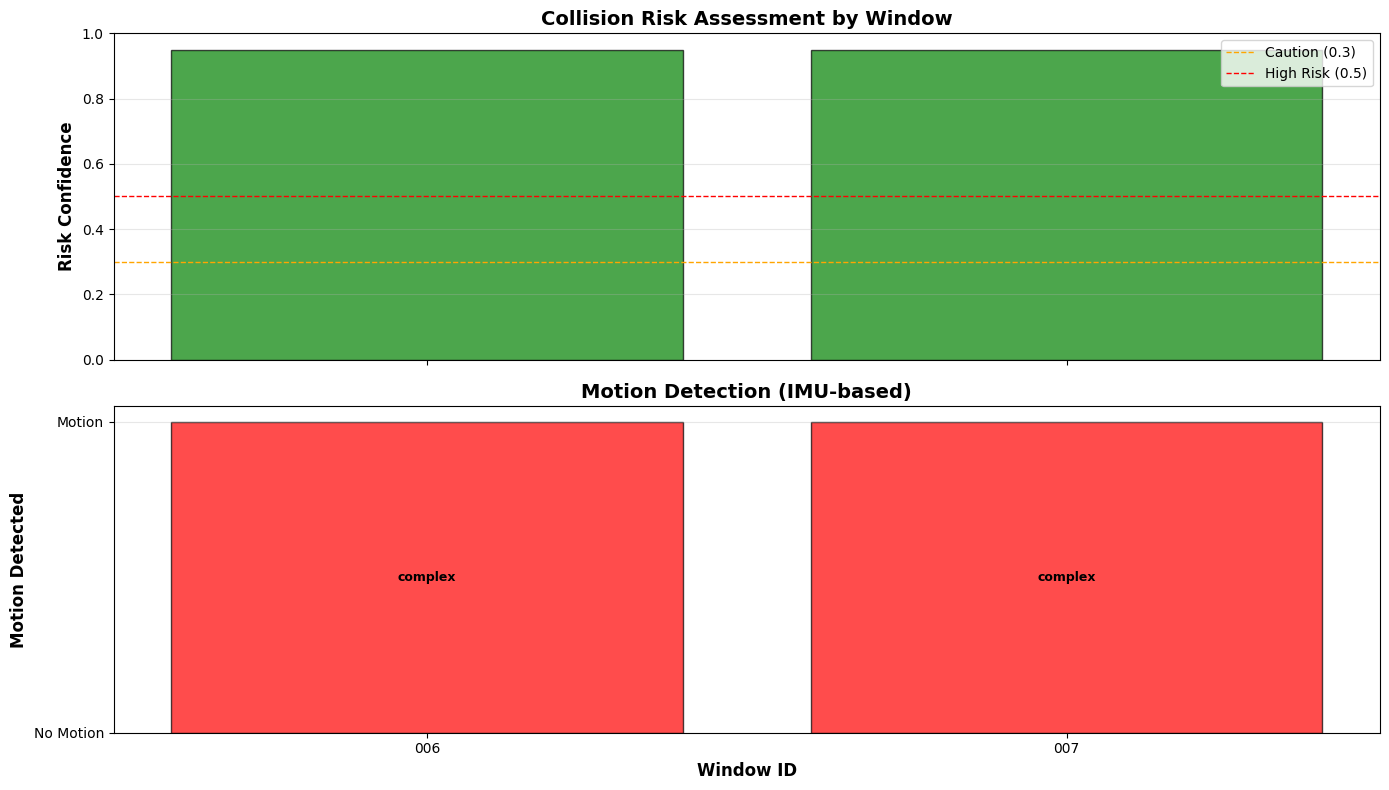


📊 STATISTICS:
--------------------------------------------------------------------------------
Motion - Detection rate: 0.0%
Motion - Max accel: 0.0000 m/s²
Motion - Max angular vel: 0.0000 rad/s
Motion - Assessment: N/A


In [12]:
if result:
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Extract data from the correct paths
    full_analysis = result.get('full_analysis', {})
    collision_data = full_analysis.get('collision', {})
    motion_data = full_analysis.get('motion', {})
    
    collision_events = collision_data.get('collision_events', [])
    motion_windows = motion_data.get('per_window_motion', [])
    
    if collision_events and motion_windows:
        # Prepare data
        windows = [w['window_id'] for w in collision_events]
        risk_levels = [w['collision_risk_level'] for w in collision_events]
        risk_scores = [w.get('risk_confidence', 0) for w in collision_events]
        motion_detected = [w['motion_detected'] for w in motion_windows]
        motion_types = [w['motion_type'] for w in motion_windows]
        
        # Create figure
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        
        # Plot 1: Collision risk
        color_map = {'none': 'green', 'low': 'lightgreen', 'medium': 'orange', 'high': 'red', 'critical': 'darkred'}
        colors = [color_map.get(level, 'gray') for level in risk_levels]
        
        ax1.bar(range(len(windows)), risk_scores, color=colors, alpha=0.7, edgecolor='black')
        ax1.axhline(y=0.3, color='orange', linestyle='--', linewidth=1, label='Caution (0.3)')
        ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='High Risk (0.5)')
        ax1.set_ylabel('Risk Confidence', fontsize=12, fontweight='bold')
        ax1.set_title('Collision Risk Assessment by Window', fontsize=14, fontweight='bold')
        ax1.legend(loc='upper right')
        ax1.grid(axis='y', alpha=0.3)
        ax1.set_ylim(0, 1.0)
        
        # Plot 2: Motion detection
        motion_values = [1 if m else 0 for m in motion_detected]
        motion_colors = ['red' if m else 'lightgray' for m in motion_detected]
        ax2.bar(range(len(windows)), motion_values, color=motion_colors, alpha=0.7, edgecolor='black')
        
        # Add motion type labels
        for i, (detected, mtype) in enumerate(zip(motion_detected, motion_types)):
            if detected:
                ax2.text(i, 0.5, mtype, ha='center', va='center', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Motion Detected', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Window ID', fontsize=12, fontweight='bold')
        ax2.set_title('Motion Detection (IMU-based)', fontsize=14, fontweight='bold')
        ax2.set_xticks(range(len(windows)))
        ax2.set_xticklabels(windows)
        ax2.set_yticks([0, 1])
        ax2.set_yticklabels(['No Motion', 'Motion'])
        ax2.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics - use .get() to handle missing keys gracefully
        motion_stats = motion_data.get('overall_stats', {})
        
        print()
        print("📊 STATISTICS:")
        print("-" * 80)
        print(f"Motion - Detection rate: {motion_stats.get('motion_detection_rate', 0)*100:.1f}%")
        print(f"Motion - Max accel: {motion_stats.get('max_horizontal_accel_mps2', 0):.4f} m/s²")
        print(f"Motion - Max angular vel: {motion_stats.get('max_angular_velocity_radps', 0):.4f} rad/s")
        print(f"Motion - Assessment: {motion_stats.get('overall_assessment', 'N/A')}")
    else:
        print("⚠️ No per-window data available for visualization")
else:
    print("⚠️ No results available. Please run the workflow first (cell 5).")

## 9. Export Results

Save the complete analysis report to JSON for further processing or sharing.

In [13]:
if result:
    # Report is already saved by run_odd_workflow()
    output_path = Path(SCENARIO_PATH) / "odd_analysis_report.json"
    
    if output_path.exists():
        file_size = output_path.stat().st_size / 1024
        print(f"✅ Results saved to:")
        print(f"   {output_path}")
        print(f"   Size: {file_size:.1f} KB")
        
        # Optionally, save to a different location
        # import json
        # custom_path = project_root / "my_analysis_results.json"
        # with open(custom_path, 'w') as f:
        #     json.dump(result, f, indent=2)
        # print(f"\n📁 Also saved to: {custom_path}")
    else:
        print("⚠️ Report file not found at expected location")
    
    # Access the result directly
    print()
    print("💡 TIP: Access results programmatically:")
    print("   result['report']                                # Human-readable report")
    print("   result['full_analysis']['perception']           # Perception data")
    print("   result['full_analysis']['motion']               # Motion data")
    print("   result['full_analysis']['collision']            # Collision data")
    print("   result['full_analysis']['odd_spec']             # Parsed ODD spec")
    print("   result['full_analysis']['cod_classification']   # COD classification")
    print("   result['full_analysis']['odd_compliance']       # Compliance analysis")
else:
    print("⚠️ No results to export. Please run the workflow first (cell 5).")

✅ Results saved to:
   /workspaces/go2-odd-observer/data/processed/runs/sim_run_test/odd_analysis_report.json
   Size: 10.8 KB

💡 TIP: Access results programmatically:
   result['report']                                # Human-readable report
   result['full_analysis']['perception']           # Perception data
   result['full_analysis']['motion']               # Motion data
   result['full_analysis']['collision']            # Collision data
   result['full_analysis']['odd_spec']             # Parsed ODD spec
   result['full_analysis']['cod_classification']   # COD classification
   result['full_analysis']['odd_compliance']       # Compliance analysis


## Next Steps

### 🎯 Customize Your Analysis

1. **Modify the ODD** (cell 3) to match your robot's design constraints
2. **Test different scenarios** (cell 4) to analyze various datasets
3. **Adjust parameters** by editing the ODD description

### 📊 Advanced Usage

- **Compare scenarios**: Run the workflow on multiple datasets and compare results
- **Parameter sensitivity**: Test how ODD threshold changes affect compliance
- **Custom visualizations**: Access `result` dictionary to create your own plots

### 🔍 Dive Deeper

- **View agent implementations**: `odd_agents/agents/` directory
- **Understand the workflow**: `odd_agents/workflow.py`
- **Read documentation**: `docs/` directory
- **Factory pattern explanation**: `docs/FACTORY_PATTERN.md`

### 🚀 Production Deployment

To use this in production:
1. Preprocess ROS2 bags: `python scripts/extract_windows.py`
2. Run analysis: `python scripts/odd_workflow.py`
3. Automate with CI/CD for continuous monitoring

---

**Questions?** Check the project documentation or explore the source code!